# E1: EfficientNet-B0 with Adam Optimizer

1. Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np  
import os
import random

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import torch
import torch.nn as nn   
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models

2. Device Configuration

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


3. Dataset Paths

In [3]:
data_dir = "chest_xray"

train_dir = os.path.join(data_dir, "train") 
test_dir = os.path.join(data_dir, "test")
val_dir = os.path.join(data_dir, "val")

4. Transform

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

5. Load Dataset

In [5]:
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms) 
test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes
print(f"Classes: {class_names}")

Classes: ['NORMAL', 'PNEUMONIA']


In [53]:
# calculate the dataset sizes for each class separately
class_counts = {class_name: 0 for class_name in class_names}    
train_size = len(train_data)
for data in train_data:
    label = data[1]
    class_counts[class_names[label]] += 1   



6. Show Random 6 images


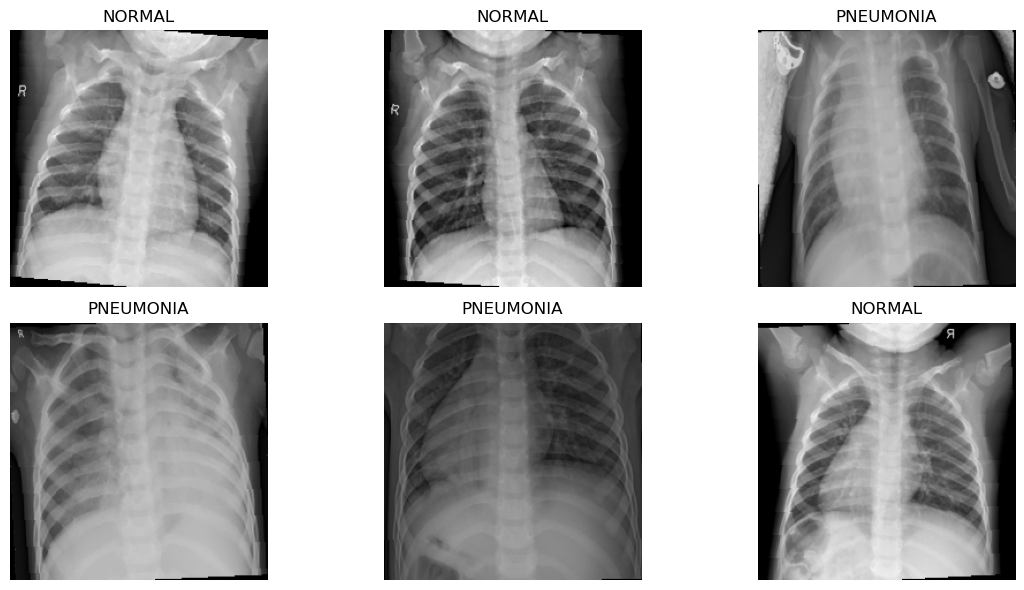

In [6]:
def show_sample_images(data_loader, class_names, num_images=6):
    images, labels = next(iter(data_loader))
    images = images[:num_images]
    labels = labels[:num_images]
    
    plt.figure(figsize=(12, 6))

    for i in range(num_images):
        plt.subplot(2, 3, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

show_sample_images(train_loader, class_names)


7. Load EfficientNet-B0

In [7]:
model = models.efficientnet_b0(pretrained=True)

c:\Users\ASUS\AppData\Local\r-miniconda\envs\pneumonia-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ASUS\AppData\Local\r-miniconda\envs\pneumonia-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


8. Freeze Layers

In [8]:
for param in model.parameters():
    param.requires_grad = False

9. Modify Classifier

In [9]:
model.add_module("classifier", nn.Linear(model.classifier[1].in_features, len(class_names)))
model = model.to(device)

10. Loss & Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

11. Training Loop + Metrics

In [11]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

epochs = 50  # Max epochs, but will stop early if no improvement

# Early stopping parameters
best_val_acc = 0
patience = 3  # Stop if validation accuracy doesn't improve for 3 consecutive epochs
patience_counter = 0
best_epoch = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / total
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= val_total
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}", end="")
    
    # Early stopping logic
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(" ✓ (Best)")
    else:
        patience_counter += 1
        print(f" (No improvement: {patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n🛑 Early Stopping at Epoch {epoch+1}")
            print(f"Best model found at Epoch {best_epoch} with Val Acc: {best_val_acc:.4f}")
            break

# Load the best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Best model loaded (Epoch {best_epoch})")

Epoch 1/50 - Train Loss: 0.2491, Train Acc: 0.9055 - Val Loss: 0.1363, Val Acc: 0.9375 ✓ (Best)
Epoch 2/50 - Train Loss: 0.1731, Train Acc: 0.9388 - Val Loss: 0.0981, Val Acc: 1.0000 ✓ (Best)
Epoch 3/50 - Train Loss: 0.1588, Train Acc: 0.9396 - Val Loss: 0.1016, Val Acc: 1.0000 (No improvement: 1/3)
Epoch 4/50 - Train Loss: 0.1494, Train Acc: 0.9448 - Val Loss: 0.0922, Val Acc: 1.0000 (No improvement: 2/3)
Epoch 5/50 - Train Loss: 0.1459, Train Acc: 0.9458 - Val Loss: 0.0734, Val Acc: 1.0000 (No improvement: 3/3)

🛑 Early Stopping at Epoch 5
Best model found at Epoch 2 with Val Acc: 1.0000

✓ Best model loaded (Epoch 2)


In [12]:
# Display Early Stopping Summary
print("\n" + "="*50)
print("EARLY STOPPING SUMMARY")
print("="*50)
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Training Epochs Executed: {len(train_losses)}")
print(f"Epochs Saved: {len(train_losses) - best_epoch}")
print("="*50)


EARLY STOPPING SUMMARY
Best Epoch: 2
Best Validation Accuracy: 1.0000
Training Epochs Executed: 5
Epochs Saved: 3


12. Plot Loss

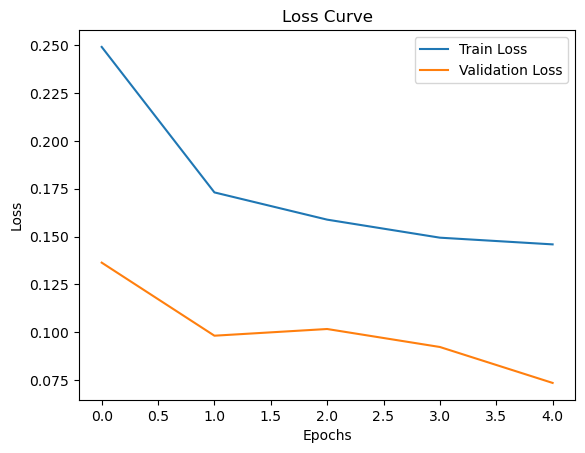

In [13]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

13. Plot Accuracy

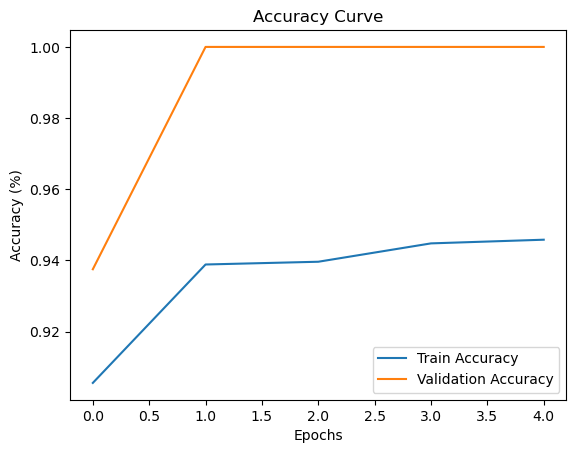

In [14]:
plt.figure()
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

14. Test Prediction

In [15]:
y_true, y_pred = [], []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [16]:
# accuracy of the model in one line
accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.8910


15. Confution Matrix

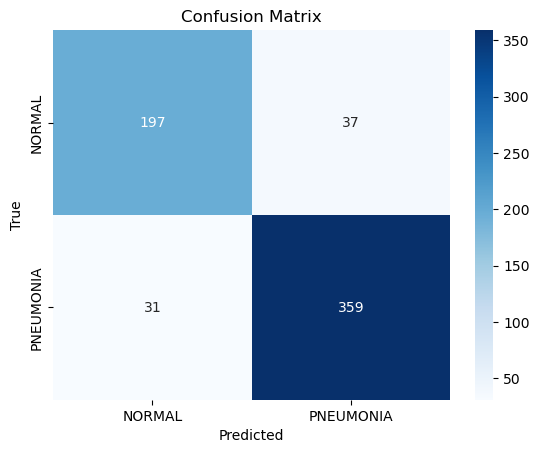

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=class_names, 
             yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')  
plt.title('Confusion Matrix')
plt.show()

16. Classification Report

In [18]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.86      0.84      0.85       234
   PNEUMONIA       0.91      0.92      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



17. Save Model

In [19]:
torch.save(model.state_dict(), "model/pneumonia_classifier.pth")

Predicted: PNEUMONIA
Actual: PNEUMONIA
Confidence: 98.86%


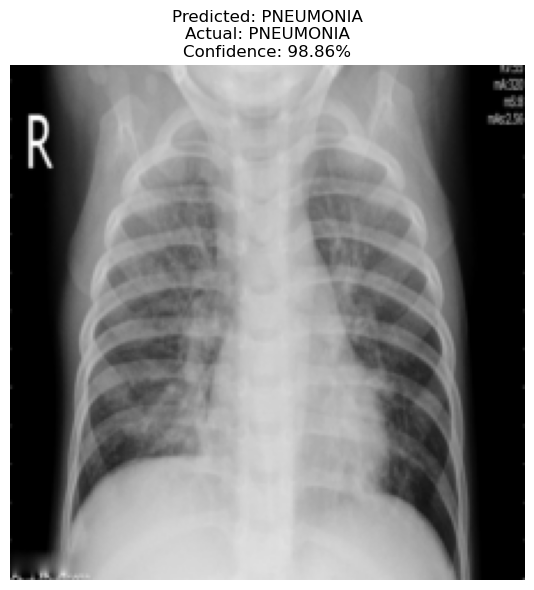

In [30]:
# Get a sample image from the test dataset
sample_image, sample_label = test_data[468]

# Add batch dimension
sample_image_batch = sample_image.unsqueeze(0).to(device)

# Pass through model
with torch.no_grad():
    output = model_check(sample_image_batch)

# Get prediction
predicted_idx = torch.argmax(output).item()
predicted_class = class_names[predicted_idx]
true_class = class_names[sample_label]
confidence = torch.softmax(output, dim=1)[0][predicted_idx].item()

# Display results
print("="*50)
print(f"Predicted: {predicted_class}")
print(f"Actual: {true_class}")
print(f"Confidence: {confidence:.2%}")
print("="*50)

# Visualize the image with prediction
plt.figure(figsize=(6, 6))
img = sample_image.permute(1, 2, 0).numpy()
plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_class}\nActual: {true_class}\nConfidence: {confidence:.2%}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [36]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.efficientnet_b0(weights=None)

model.classifier = nn.Linear(
    model.classifier[1].in_features,
    2
)

model.load_state_dict(
    torch.load(
        "model/pneumonia_classifier.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [41]:
for i, layer in enumerate(model.features):
    print(i, layer)

0 Conv2dNormActivation(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)
1 Sequential(
  (0): MBConv(
    (block): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
        (activation): SiLU(inplace=True)
        (scale_activation): Sigmoid()
      )
      (2): Conv2dNormActivation(
        (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0

In [42]:
# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [43]:
# load x-ray image
image_path = "chest_xray/test/NORMAL/IM-0001-0001.jpeg"

img = Image.open(image_path).convert("RGB")

input_tensor = transform(img).unsqueeze(0).to(device)

In [44]:
# get model prediction
with torch.no_grad():

    output = model(input_tensor)

    probabilities = torch.softmax(output, dim=1)

    confidence, predicted = torch.max(
        probabilities,
        1
    )

class_names = ["NORMAL", "PNEUMONIA"]

print(
    f"Prediction: {class_names[predicted.item()]}"
)

print(
    f"Confidence: {confidence.item()*100:.2f}%"
)

Prediction: NORMAL
Confidence: 89.79%


In [49]:
from pytorch_grad_cam import GradCAM

target_layers = [model.features[-1][0]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [ ]:
# import necessary utilities for visualization
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Create the cam object and compute the CAM
targets = [ClassifierOutputTarget(predicted.item())]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

In [50]:
rgb_img = np.array(
    img.resize((224, 224))
).astype(np.float32) / 255.0

In [51]:
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

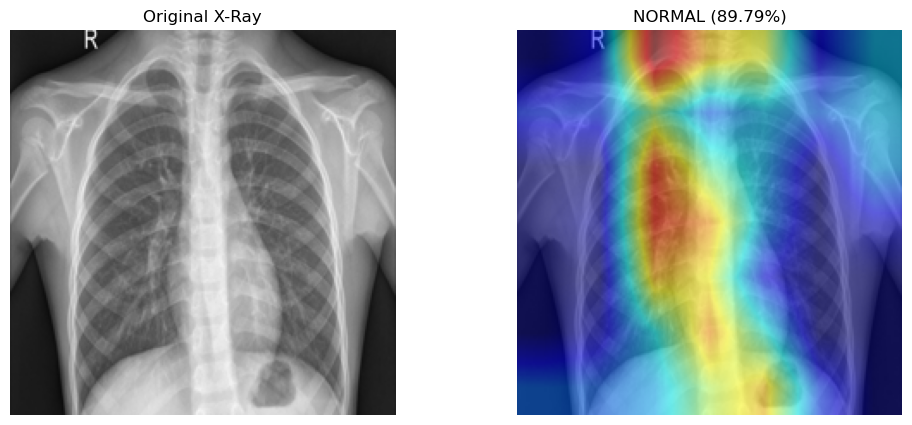

In [52]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original X-Ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title(
    f"{class_names[predicted.item()]} "
    f"({confidence.item()*100:.2f}%)"
)
plt.axis("off")

plt.show()